## Loss Function Visualization
The following loss functions are visualized:
- Step
- MSE
- Sigmoid (Activation Function) + Binary Cross Entropy Loss Function
- Softmax (Activation Function) + Multiclass Cross Entropy Loss Function

For further notes and observations on the listed loss functions, scroll to the bottom past the visualized functions.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F

device = "cpu"

x = torch.linspace(-3, 3, 500, device=device, requires_grad=True)
y_true_binary = torch.tensor(1.0, device=device)       # for binary losses
y_true_continuous = torch.tensor(0.0, device=device)   # for MSE/regression

In [2]:
step_loss = torch.where(torch.sign(x) == torch.sign(y_true_binary), 0.0, 1.0)

mse_loss = (x - y_true_continuous)**2

# Sigmoid + Cross Entropy (Binary)
sigmoid = torch.sigmoid(x)
sigmoid_bce_loss = F.binary_cross_entropy(sigmoid, y_true_binary.expand_as(sigmoid), reduction='none')

# Softmax + Cross Entropy (Multiclass)
logits = torch.stack([x, -x, 0.5*x], dim=1)
y_true_class = torch.zeros(x.shape[0], dtype=torch.long, device=device)
softmax_ce_loss = F.cross_entropy(logits, y_true_class, reduction='none')

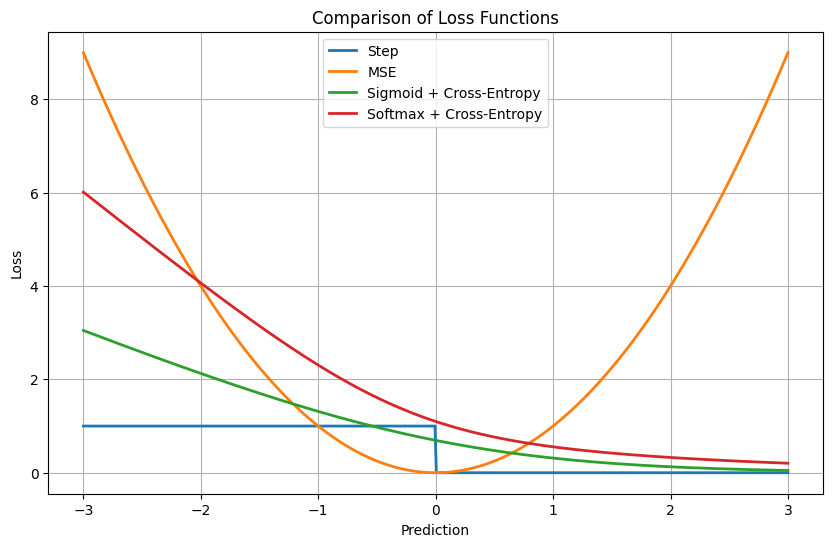

In [3]:
plt.figure(figsize=(10, 6))
plt.plot(x.detach().cpu(), step_loss.detach().cpu(), label="Step", linewidth=2)
plt.plot(x.detach().cpu(), mse_loss.detach().cpu(), label="MSE", linewidth=2)
plt.plot(x.detach().cpu(), sigmoid_bce_loss.detach().cpu(), label="Sigmoid + Cross-Entropy", linewidth=2)
plt.plot(x.detach().cpu(), softmax_ce_loss.detach().cpu(), label="Softmax + Cross-Entropy", linewidth=2)

plt.xlabel("Prediction")
plt.ylabel("Loss")
plt.title("Comparison of Loss Functions")
plt.legend()
plt.grid(True)
plt.show()

### Observations and Notes on Loss Functions in Deep Learning

**Step**: the step loss function is only concerned whether a prediction is correct or incorrect.
- If the loss is returning 1, the prediction is incorrect. If loss returns 0, the prediction is correct.
- This is easily distinguishable in the plot above as we can see the sharp drop in loss from 1 to 0 once the model is making correct predictions.
- While a notable loss function, step is **very rarely applicable** in deep learning as learning relies on gradient descent. Deep learning depends on a "smooth" function to best compute its gradients.

**Mean Squared Error (MSE) Loss Function**: measures the average squared difference between predicted values and the actual values in the dataset.
- LOW MSE indicates predictions are close to actual values / ground truth.
- Why do we square the difference? Squaring removes negatives and heavily penalizes outliers (which also becomes MSEs weakness)
- Advantages: simple, smooth gradients (better than step), and works well for regression
- Disadvantages: Sensitive to outliers, a single error can heavily dominate the loss.

**Sigmoid Loss Function**: while often referred to as a loss function, the sigmoid function is actually used as an activation function.
- Sigmoid converts model outputs into probabilities --> converts any real number into a value between 0 and 1
$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$
- Once we have our probabilities, we then use **Binary Cross-Entropy (BCE)** to get our loss on the prediction.
$$
\text{BCE} = - \big(y \log(\hat{y}) + (1-y) \log(1-\hat{y})\big)
$$
- **Vanishing Gradient**: an important issue with sigmoid + BCE is the vanishing gradient problem. For very large positive or negative inputs, the gradients become very small which slow learning.
- For this reason, modern models often use ReLu inside hidden layers and wait until the final output layer before using the sigmoid function.

**Softmax Loss Function**: similar idea to sigmoid loss function, but softmax and cross-entropy deal with multiclass logits.
- Softmax function converts outputted logits to predictions that sum to 1.
$$
\sigma(\mathbf{z})_i = \frac{e^{z_i}}{\sum_{j=1}^{C} e^{z_j}} \quad
$$
- Ex: [0.65, 0.10, 0.25]
- Cross-Entropy will then take these predictions and measure the difference between the true distribution and the predicted distribution.
$$
CE = - \sum_{i=1}^C y_i \log(p_i)
$$
